### Reader

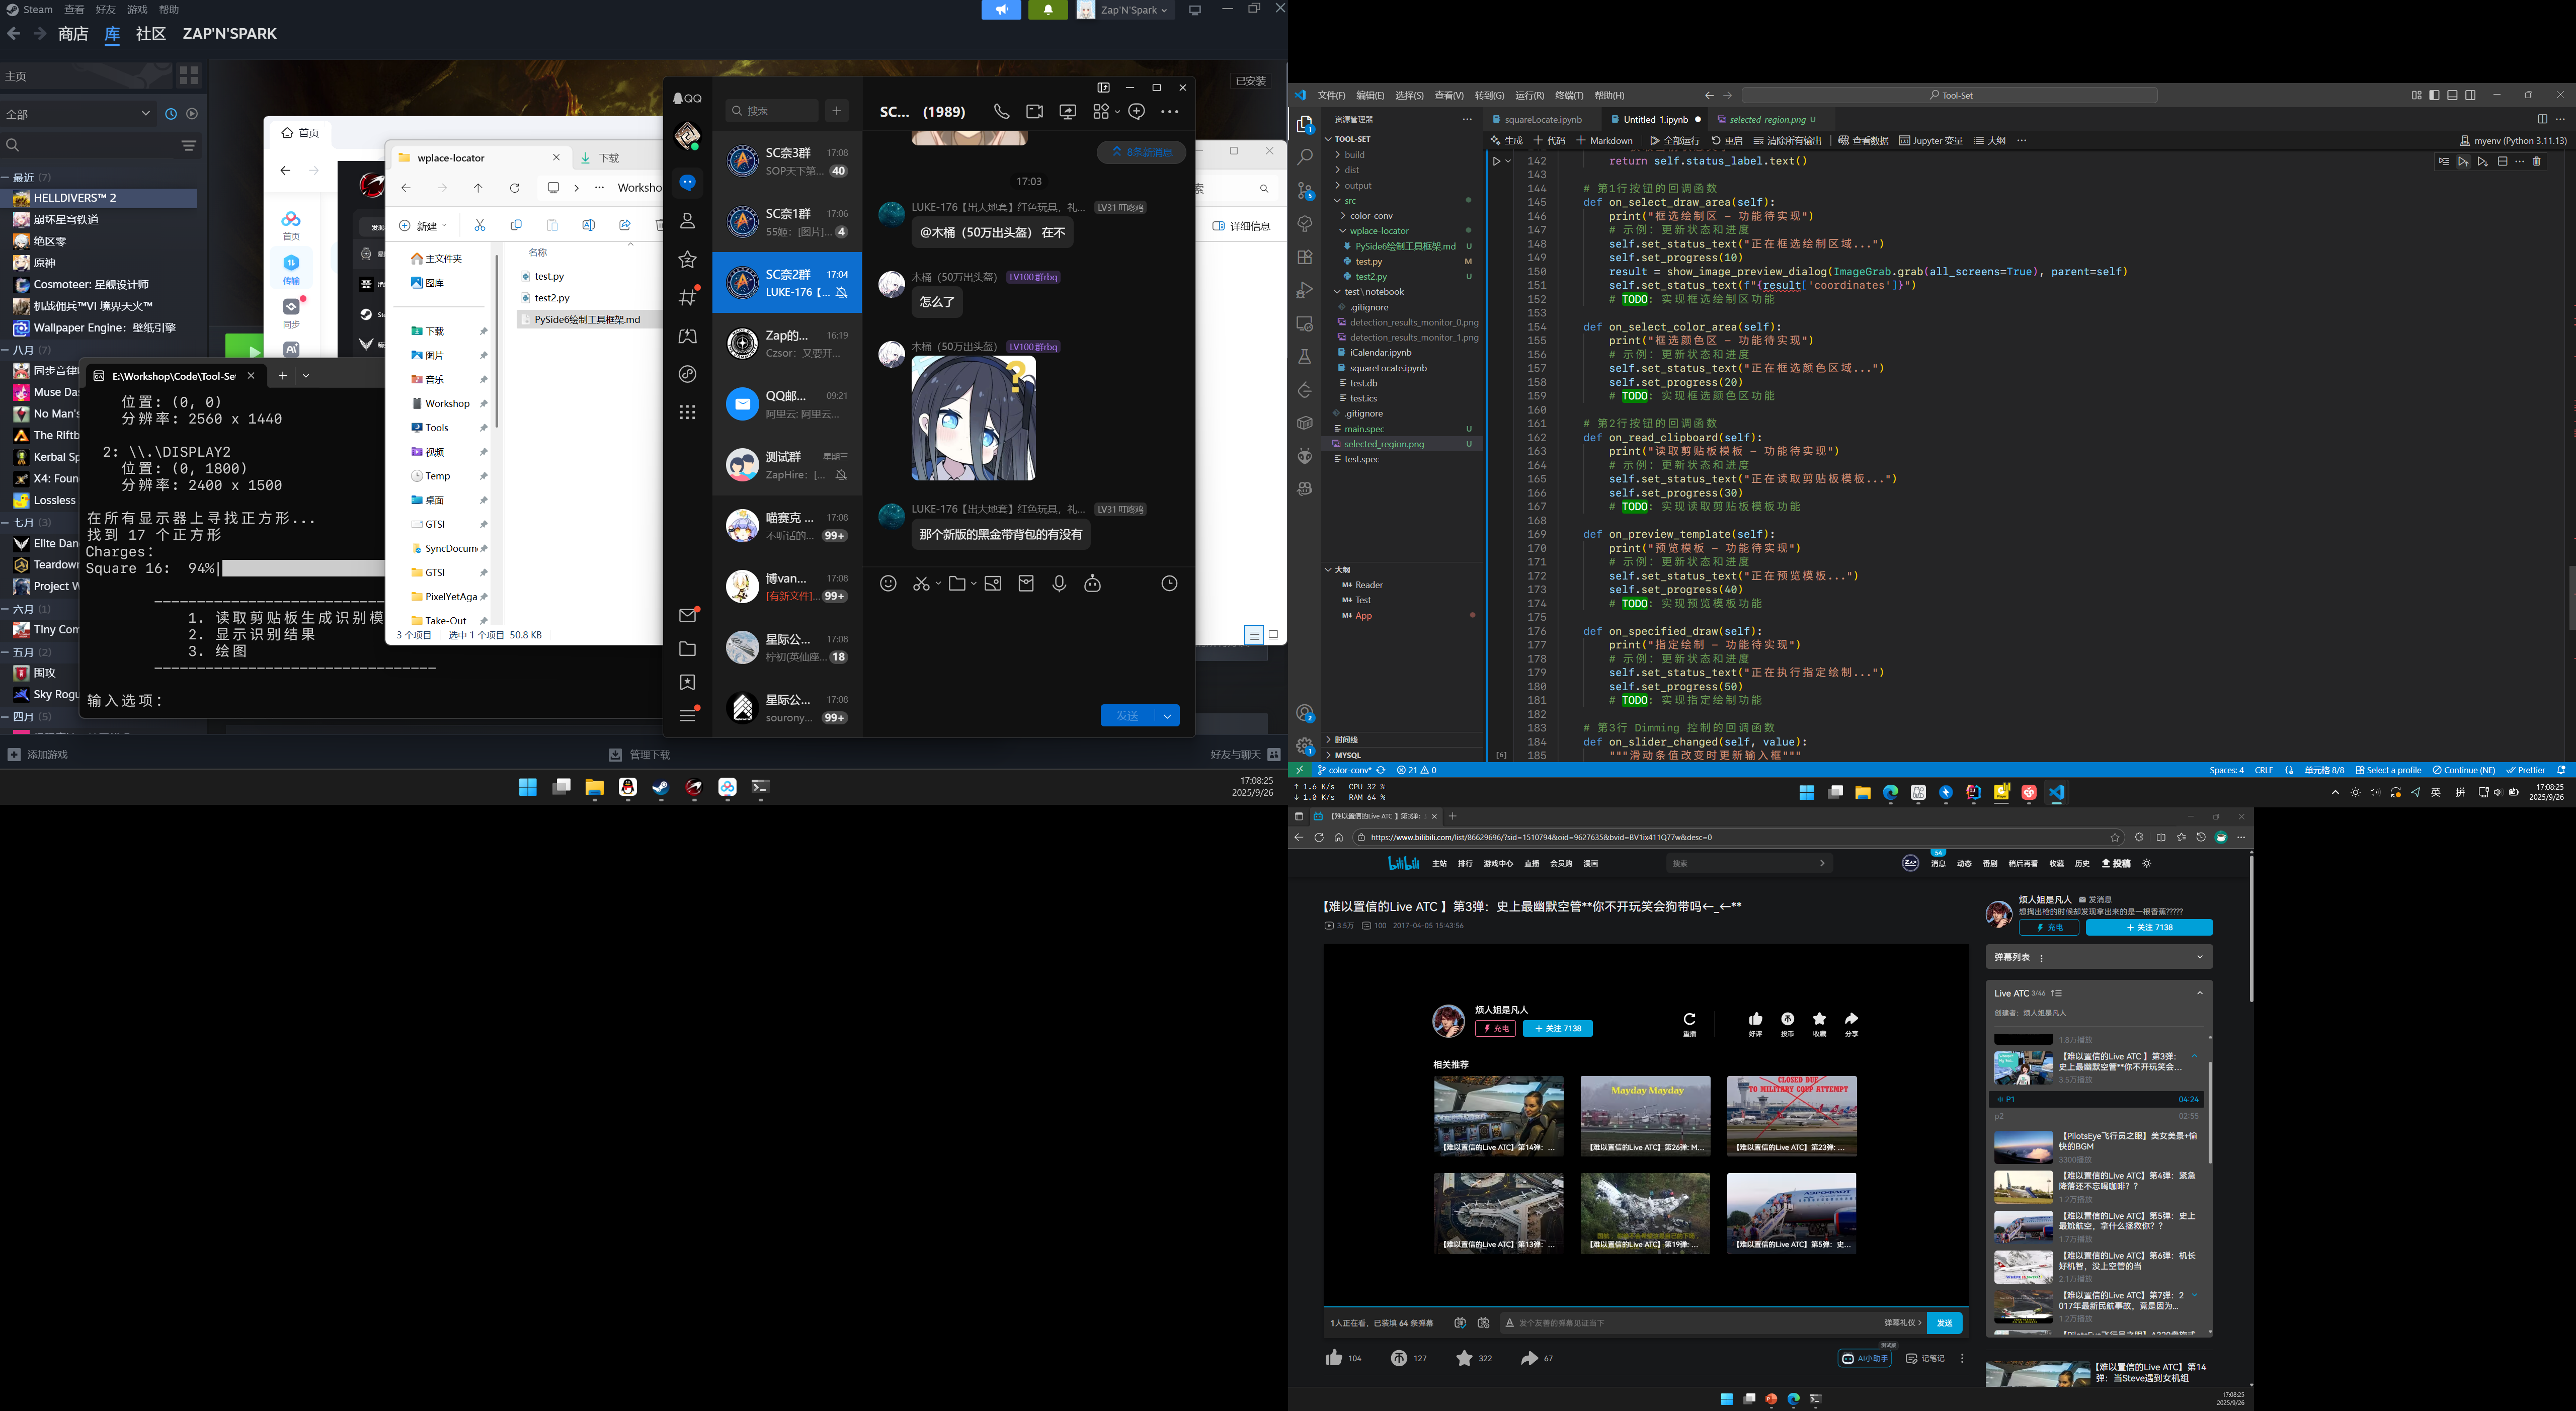

In [1]:
from PIL import Image, ImageGrab

ImageGrab.grab(all_screens=True)



### Test

In [2]:
import screeninfo, pprint
for i, monitor in enumerate(screeninfo.get_monitors()):
    pprint.pprint({
        'index': i,
        'name': monitor.name if hasattr(monitor, 'name') else f"Monitor {i+1}",
        'x': monitor.x,
        'y': monitor.y,
        'width': monitor.width,
        'height': monitor.height,
        'is_primary': monitor.is_primary if hasattr(monitor, 'is_primary') else (i == 0)
    })

{'height': 1600,
 'index': 0,
 'is_primary': False,
 'name': '\\\\.\\DISPLAY1',
 'width': 2560,
 'x': -2560,
 'y': -165}
{'height': 1440,
 'index': 1,
 'is_primary': True,
 'name': '\\\\.\\DISPLAY5',
 'width': 2560,
 'x': 0,
 'y': 0}
{'height': 1200,
 'index': 2,
 'is_primary': False,
 'name': '\\\\.\\DISPLAY2',
 'width': 1920,
 'x': 0,
 'y': 1440}


### App

In [1]:
import sys
from PySide6.QtWidgets import (
    QApplication, QDialog, QVBoxLayout, QHBoxLayout, 
    QPushButton, QLabel, QScrollArea, QWidget
)
from PySide6.QtCore import Qt, QRect, Signal, QPoint
from PySide6.QtGui import QPixmap, QPainter, QPen, QColor, QWheelEvent, QMouseEvent, QCursor
from PIL import Image
import numpy as np

class ImagePreviewWidget(QLabel):
    """图像预览和选择控件 - 支持右键拖拽移动"""
    
    def __init__(self, pil_image):
        super().__init__()
        self.original_pil_image = pil_image
        self.scale_factor = 1.0
        self.selection_rect = QRect()
        
        # 选择相关状态
        self.selecting = False
        self.selection_start_point = QPoint()
        
        # 拖拽移动相关状态
        self.panning = False
        self.pan_start_point = QPoint()
        self.image_offset = QPoint(0, 0)  # 图像偏移量
        
        # 设置控件属性
        self.setAlignment(Qt.AlignCenter)
        self.setMinimumSize(400, 300)
        self.setStyleSheet("border: 1px solid gray; background-color: #f0f0f0;")
        
        # 转换PIL图像为QPixmap
        self.original_pixmap = self.pil_to_qpixmap(pil_image)
        self.update_display()
        
    def pil_to_qpixmap(self, pil_image):
        """将PIL图像转换为QPixmap"""
        # 确保图像是RGB格式
        if pil_image.mode != 'RGB':
            pil_image = pil_image.convert('RGB')
        
        # 转换为numpy数组
        img_array = np.array(pil_image)
        height, width, channel = img_array.shape
        bytes_per_line = 3 * width
        
        # 创建QPixmap
        from PySide6.QtGui import QImage
        q_image = QImage(img_array.data, width, height, bytes_per_line, QImage.Format_RGB888)
        return QPixmap.fromImage(q_image)
    
    def update_display(self):
        """更新显示的图像"""
        # 缩放图像
        scaled_pixmap = self.original_pixmap.scaled(
            int(self.original_pixmap.width() * self.scale_factor),
            int(self.original_pixmap.height() * self.scale_factor),
            Qt.KeepAspectRatio,
            Qt.SmoothTransformation
        )
        
        # 创建显示用的pixmap，考虑偏移
        display_pixmap = self.create_display_pixmap(scaled_pixmap)
        
        # 如果有选择区域，绘制选择框
        if not self.selection_rect.isEmpty():
            display_pixmap = self.draw_selection_on_pixmap(display_pixmap, scaled_pixmap.size())
        
        self.setPixmap(display_pixmap)
    
    def create_display_pixmap(self, scaled_pixmap):
        """创建带偏移的显示pixmap"""
        widget_size = self.size()
        
        # 创建与控件大小相同的空白pixmap
        display_pixmap = QPixmap(widget_size)
        display_pixmap.fill(QColor(240, 240, 240))  # 背景色
        
        # 计算图像在控件中的位置（考虑偏移）
        image_pos = self.calculate_image_position(scaled_pixmap.size())
        
        # 绘制图像到显示pixmap上
        painter = QPainter(display_pixmap)
        painter.drawPixmap(image_pos, scaled_pixmap)
        painter.end()
        
        return display_pixmap
    
    def calculate_image_position(self, image_size):
        """计算图像在控件中的位置"""
        widget_size = self.size()
        
        # 基础居中位置
        center_x = (widget_size.width() - image_size.width()) // 2
        center_y = (widget_size.height() - image_size.height()) // 2
        
        # 加上偏移
        final_x = center_x + self.image_offset.x()
        final_y = center_y + self.image_offset.y()
        
        return QPoint(final_x, final_y)
    
    def draw_selection_on_pixmap(self, display_pixmap, scaled_image_size):
        """在显示pixmap上绘制选择框"""
        if self.selection_rect.isEmpty():
            return display_pixmap
            
        painter = QPainter(display_pixmap)
        painter.setPen(QPen(QColor(255, 0, 0), 2, Qt.DashLine))
        
        # 计算选择区域在显示pixmap中的位置
        image_pos = self.calculate_image_position(scaled_image_size)
        
        scaled_rect = QRect(
            int(self.selection_rect.x() * self.scale_factor) + image_pos.x(),
            int(self.selection_rect.y() * self.scale_factor) + image_pos.y(),
            int(self.selection_rect.width() * self.scale_factor),
            int(self.selection_rect.height() * self.scale_factor)
        )
        
        painter.drawRect(scaled_rect)
        painter.end()
        return display_pixmap
    
    def wheelEvent(self, event: QWheelEvent):
        """鼠标滚轮事件 - 缩放"""
        # 获取滚轮滚动方向
        delta = event.angleDelta().y()
        
        # 计算缩放因子
        scale_in = 1.15
        scale_out = 1 / scale_in
        
        old_scale = self.scale_factor
        
        if delta > 0:
            # 放大
            self.scale_factor *= scale_in
        else:
            # 缩小
            self.scale_factor *= scale_out
        
        # 限制缩放范围
        self.scale_factor = max(0.1, min(self.scale_factor, 5.0))
        
        # 如果缩放发生变化，调整偏移以保持鼠标位置为中心
        if self.scale_factor != old_scale:
            self.adjust_offset_for_zoom(event.position().toPoint(), old_scale)
        
        self.update_display()
    
    def adjust_offset_for_zoom(self, mouse_pos, old_scale):
        """调整偏移以保持缩放中心"""
        # 计算缩放比例变化
        scale_ratio = self.scale_factor / old_scale
        
        # 获取当前图像位置
        widget_size = self.size()
        old_image_size = self.original_pixmap.size() * old_scale
        old_image_pos = self.calculate_image_position(old_image_size)
        
        # 计算鼠标相对于图像的位置
        relative_mouse_x = mouse_pos.x() - old_image_pos.x()
        relative_mouse_y = mouse_pos.y() - old_image_pos.y()
        
        # 计算新的偏移
        new_relative_x = relative_mouse_x * scale_ratio
        new_relative_y = relative_mouse_y * scale_ratio
        
        offset_adjust_x = relative_mouse_x - new_relative_x
        offset_adjust_y = relative_mouse_y - new_relative_y
        
        self.image_offset.setX(self.image_offset.x() + int(offset_adjust_x))
        self.image_offset.setY(self.image_offset.y() + int(offset_adjust_y))
    
    def mousePressEvent(self, event: QMouseEvent):
        """鼠标按下事件"""
        if event.button() == Qt.LeftButton:
            # 左键开始选择
            original_pos = self.map_to_original_coords(event.position().toPoint())
            if original_pos is not None:
                self.selecting = True
                self.selection_start_point = original_pos
                self.selection_rect = QRect()
                
        elif event.button() == Qt.RightButton:
            # 右键开始拖拽
            self.panning = True
            self.pan_start_point = event.position().toPoint()
            self.setCursor(QCursor(Qt.ClosedHandCursor))
    
    def mouseMoveEvent(self, event: QMouseEvent):
        """鼠标移动事件"""
        if self.selecting and event.buttons() & Qt.LeftButton:
            # 左键拖拽选择
            current_pos = self.map_to_original_coords(event.position().toPoint())
            if current_pos is not None:
                # 创建选择矩形
                self.selection_rect = QRect(
                    min(self.selection_start_point.x(), current_pos.x()),
                    min(self.selection_start_point.y(), current_pos.y()),
                    abs(current_pos.x() - self.selection_start_point.x()),
                    abs(current_pos.y() - self.selection_start_point.y())
                )
                
                # 确保选择区域在图像范围内
                img_rect = QRect(0, 0, self.original_pixmap.width(), self.original_pixmap.height())
                self.selection_rect = self.selection_rect.intersected(img_rect)
                
                self.update_display()
                
        elif self.panning and event.buttons() & Qt.RightButton:
            # 右键拖拽移动
            current_pos = event.position().toPoint()
            delta = current_pos - self.pan_start_point
            
            self.image_offset += delta
            self.pan_start_point = current_pos
            
            self.update_display()
        else:
            # 鼠标悬停时更新光标样式
            if self.is_mouse_over_image(event.position().toPoint()):
                if not self.selecting and not self.panning:
                    self.setCursor(QCursor(Qt.ArrowCursor))
            else:
                self.setCursor(QCursor(Qt.ArrowCursor))
    
    def mouseReleaseEvent(self, event: QMouseEvent):
        """鼠标释放事件"""
        if event.button() == Qt.LeftButton:
            self.selecting = False
        elif event.button() == Qt.RightButton:
            self.panning = False
            self.setCursor(QCursor(Qt.ArrowCursor))
    
    def is_mouse_over_image(self, mouse_pos):
        """检查鼠标是否在图像区域内"""
        scaled_size = self.original_pixmap.size() * self.scale_factor
        image_pos = self.calculate_image_position(scaled_size)
        image_rect = QRect(image_pos, scaled_size)
        return image_rect.contains(mouse_pos)
    
    def map_to_original_coords(self, widget_point):
        """将控件坐标映射到原始图像坐标"""
        # 计算当前缩放图像的尺寸和位置
        scaled_size = self.original_pixmap.size() * self.scale_factor
        image_pos = self.calculate_image_position(scaled_size)
        
        # 检查点击是否在图像区域内
        image_rect = QRect(image_pos, scaled_size)
        if not image_rect.contains(widget_point):
            return None
        
        # 计算相对于图像的坐标
        relative_x = widget_point.x() - image_pos.x()
        relative_y = widget_point.y() - image_pos.y()
        
        # 映射到原始图像坐标
        original_x = int(relative_x / self.scale_factor)
        original_y = int(relative_y / self.scale_factor)
        
        # 确保坐标在有效范围内
        original_x = max(0, min(original_x, self.original_pixmap.width() - 1))
        original_y = max(0, min(original_y, self.original_pixmap.height() - 1))
        
        return QPoint(original_x, original_y)
    
    def reset_view(self):
        """重置视图（缩放和偏移）"""
        self.scale_factor = 1.0
        self.image_offset = QPoint(0, 0)
        self.update_display()
    
    def reset_selection(self):
        """重置选择"""
        self.selection_rect = QRect()
        self.update_display()
    
    def reset_all(self):
        """重置所有（视图和选择）"""
        self.reset_view()
        self.reset_selection()
    
    def get_selection_data(self):
        """获取选择区域的数据"""
        if self.selection_rect.isEmpty():
            return None
        
        # 从PIL图像中裁剪选择区域
        left = self.selection_rect.x()
        top = self.selection_rect.y()
        right = left + self.selection_rect.width()
        bottom = top + self.selection_rect.height()
        
        # 确保坐标在有效范围内
        left = max(0, left)
        top = max(0, top)
        right = min(self.original_pil_image.width, right)
        bottom = min(self.original_pil_image.height, bottom)
        
        if left >= right or top >= bottom:
            return None
        
        # 裁剪图像
        cropped_image = self.original_pil_image.crop((left, top, right, bottom))
        
        return {
            'image': cropped_image,
            'coordinates': (left, top, right, bottom),
            'size': (right - left, bottom - top)
        }


class ImagePreviewDialog(QDialog):
    """图像预览对话框 - 更新了按钮功能"""
    
    def __init__(self, pil_image, parent=None):
        super().__init__(parent)
        self.setWindowTitle("图像预览和区域选择")
        self.setModal(True)
        self.resize(900, 700)
        
        self.selection_data = None
        
        # 创建布局
        layout = QVBoxLayout(self)
        
        # 创建图像预览控件
        self.preview_widget = ImagePreviewWidget(pil_image)
        layout.addWidget(self.preview_widget)
        
        # 创建按钮布局
        button_layout = QHBoxLayout()
        
        # 重置视图按钮
        self.reset_view_button = QPushButton("重置视图")
        self.reset_view_button.clicked.connect(self.on_reset_view)
        self.reset_view_button.setToolTip("重置缩放和位置到初始状态")
        
        # 重置选择按钮
        self.reset_selection_button = QPushButton("重置选择")
        self.reset_selection_button.clicked.connect(self.on_reset_selection)
        self.reset_selection_button.setToolTip("清除当前选择区域")
        
        button_layout.addWidget(self.reset_view_button)
        button_layout.addWidget(self.reset_selection_button)
        button_layout.addStretch()
        
        # 确认按钮
        self.confirm_button = QPushButton("确认")
        self.confirm_button.clicked.connect(self.on_confirm)
        
        button_layout.addWidget(self.confirm_button)
        
        layout.addLayout(button_layout)
        
        # 添加使用说明
        info_label = QLabel(
            "使用说明：滚轮缩放 | 左键拖动选择区域 | 右键拖动移动图像"
        )
        info_label.setStyleSheet("color: gray; font-size: 12px; padding: 5px;")
        info_label.setWordWrap(True)
        layout.addWidget(info_label)
    
    def on_reset_view(self):
        """重置视图"""
        self.preview_widget.reset_view()
    
    def on_reset_selection(self):
        """重置选择"""
        self.preview_widget.reset_selection()
    
    def on_confirm(self):
        """确认选择"""
        self.selection_data = self.preview_widget.get_selection_data()
        if self.selection_data is None:
            from PySide6.QtWidgets import QMessageBox
            QMessageBox.warning(self, "警告", "请先选择一个区域")
            return
        
        self.accept()
    
    def get_selection_data(self):
        """获取选择区域数据"""
        return self.selection_data

def show_image_preview_dialog(pil_image, parent=None):
    """显示图像预览对话框的便捷函数"""
    # 确保有QApplication实例
    app = QApplication.instance()
    if app is None:
        app = QApplication([])
    
    dialog = ImagePreviewDialog(pil_image, parent)
    
    if dialog.exec() == QDialog.Accepted:
        return dialog.get_selection_data()
    else:
        return None


In [ ]:
# 在notebook中直接调用，不需要main()
from PIL import Image, ImageGrab
pil_image = ImageGrab.grab(all_screens=True)
result = show_image_preview_dialog(pil_image)
result

In [ ]:
import sys
from PySide6.QtWidgets import (
    QApplication, QMainWindow, QWidget, QVBoxLayout, 
    QHBoxLayout, QPushButton, QLabel, QSlider, 
    QLineEdit, QSpacerItem, QSizePolicy, QProgressBar,
    QFileDialog, QMessageBox
)
from PySide6.QtCore import Qt
from PIL import Image, ImageGrab

class MainWindow(QMainWindow):
    def __init__(self):
        super().__init__()
        self.setWindowTitle("绘制工具")
        self.setMinimumSize(600, 350)
        
        # 存储选择的区域数据
        self.draw_area_data = None
        self.color_area_data = None
        
        # 创建中央窗口部件
        central_widget = QWidget()
        self.setCentralWidget(central_widget)
        
        # 创建主布局
        main_layout = QVBoxLayout(central_widget)
        main_layout.setSpacing(20)
        main_layout.setContentsMargins(20, 20, 20, 20)
        
        # 第1行：框选按钮
        row1_layout = QHBoxLayout()
        
        self.btn_select_draw_area = QPushButton("框选绘制区")
        self.btn_select_color_area = QPushButton("框选颜色区")
        
        self.btn_select_draw_area.clicked.connect(self.on_select_draw_area)
        self.btn_select_color_area.clicked.connect(self.on_select_color_area)
        
        row1_layout.addWidget(self.btn_select_draw_area)
        row1_layout.addWidget(self.btn_select_color_area)
        row1_layout.addStretch()
        
        # 第2行：模板和绘制按钮
        row2_layout = QHBoxLayout()
        
        btn_read_clipboard = QPushButton("读取剪贴板模板")
        btn_preview_template = QPushButton("预览模板")
        btn_specified_draw = QPushButton("指定绘制")
        
        btn_read_clipboard.clicked.connect(self.on_read_clipboard)
        btn_preview_template.clicked.connect(self.on_preview_template)
        btn_specified_draw.clicked.connect(self.on_specified_draw)
        
        row2_layout.addWidget(btn_read_clipboard)
        row2_layout.addWidget(btn_preview_template)
        row2_layout.addWidget(btn_specified_draw)
        row2_layout.addStretch()
        
        # 第3行：Dimming 控制
        row3_layout = QHBoxLayout()
        
        dimming_label = QLabel("Dimming")
        
        # 滑动条
        self.dimming_slider = QSlider(Qt.Horizontal)
        self.dimming_slider.setRange(0, 90)
        self.dimming_slider.setValue(0)
        self.dimming_slider.setFixedWidth(200)
        
        # 输入框
        self.dimming_input = QLineEdit()
        self.dimming_input.setText("0")
        self.dimming_input.setFixedWidth(60)
        
        # 连接信号和槽，实现联动
        self.dimming_slider.valueChanged.connect(self.on_slider_changed)
        self.dimming_input.textChanged.connect(self.on_input_changed)
        
        row3_layout.addWidget(dimming_label)
        row3_layout.addWidget(self.dimming_slider)
        row3_layout.addWidget(self.dimming_input)
        row3_layout.addStretch()
        
        # 第4行：自动绘制按钮
        row4_layout = QHBoxLayout()
        
        btn_preview_auto = QPushButton("预览自动模板")
        btn_auto_draw = QPushButton("全自动绘制")
        
        btn_preview_auto.clicked.connect(self.on_preview_auto)
        btn_auto_draw.clicked.connect(self.on_auto_draw)
        
        row4_layout.addWidget(btn_preview_auto)
        row4_layout.addWidget(btn_auto_draw)
        row4_layout.addStretch()
        
        # 第5行：进度条 (0-100)
        row5_layout = QHBoxLayout()
        
        progress_label = QLabel("进度:")
        self.progress_bar = QProgressBar()
        self.progress_bar.setRange(0, 100)
        self.progress_bar.setValue(0)
        self.progress_bar.setTextVisible(True)
        
        row5_layout.addWidget(progress_label)
        row5_layout.addWidget(self.progress_bar)
        
        # 第6行：状态文字
        row6_layout = QHBoxLayout()
        
        self.status_label = QLabel("就绪")
        self.status_label.setStyleSheet("QLabel { font-weight: bold; color: #333; }")
        
        row6_layout.addWidget(self.status_label)
        row6_layout.addStretch()
        
        # 将所有行添加到主布局
        main_layout.addLayout(row1_layout)
        main_layout.addLayout(row2_layout)
        main_layout.addLayout(row3_layout)
        main_layout.addLayout(row4_layout)
        main_layout.addLayout(row5_layout)
        main_layout.addLayout(row6_layout)
        
        # 添加垂直弹性空间，使控件靠上排列
        main_layout.addStretch()
        
    def load_image_file(self):
        """加载图像文件"""
        # file_path, _ = QFileDialog.getOpenFileName(
        #     self,
        #     "选择图像文件",
        #     "",
        #     "图像文件 (*.png *.jpg *.jpeg *.bmp *.gif *.tiff)"
        # )
        
        # if file_path:
        #     try:
        #         pil_image = Image.open(file_path)
        #         return pil_image
        #     except Exception as e:
        #         QMessageBox.critical(self, "错误", f"无法加载图像文件：{str(e)}")
        #         return None
        
        try:
            img = ImageGrab.grab(all_screens=True)
            return img
        except Exception as e:
            QMessageBox.critical(self, "错误", f"无法加载图像文件：{str(e)}")
            return None
    
    # 框选区域的回调函数
    def on_select_draw_area(self):
        """框选绘制区域"""
        self.set_status_text("请选择要加载的图像文件...")
        
        # 加载图像文件
        pil_image = self.load_image_file()
        if pil_image is None:
            self.set_status_text("取消选择图像文件")
            return
        
        self.set_status_text("正在框选绘制区域...")
        self.set_progress(10)
        
        # 显示图像预览对话框进行区域选择
        result = show_image_preview_dialog(pil_image, self)
        
        if result:
            self.draw_area_data = result
            self.set_status_text(f"绘制区域已选择 - 尺寸: {result['size']}")
            self.set_progress(30)
            
            # 更新按钮文本显示已选择
            self.btn_select_draw_area.setText(f"绘制区({result['size'][0]}x{result['size'][1]})")
            
            # 可选：保存选择的区域图像
            result['image'].save("selected_draw_area.png")
            print(f"绘制区域保存为: selected_draw_area.png")
            print(f"坐标: {result['coordinates']}")
        else:
            self.set_status_text("取消选择绘制区域")
            self.set_progress(0)
        
    def on_select_color_area(self):
        """框选颜色区域"""
        self.set_status_text("请选择要加载的图像文件...")
        
        # 加载图像文件
        pil_image = self.load_image_file()
        if pil_image is None:
            self.set_status_text("取消选择图像文件")
            return
        
        self.set_status_text("正在框选颜色区域...")
        self.set_progress(15)
        
        # 显示图像预览对话框进行区域选择
        result = show_image_preview_dialog(pil_image, self)
        
        if result:
            self.color_area_data = result
            self.set_status_text(f"颜色区域已选择 - 尺寸: {result['size']}")
            self.set_progress(35)
            
            # 更新按钮文本显示已选择
            self.btn_select_color_area.setText(f"颜色区({result['size'][0]}x{result['size'][1]})")
            
            # 可选：保存选择的区域图像
            result['image'].save("selected_color_area.png")
            print(f"颜色区域保存为: selected_color_area.png")
            print(f"坐标: {result['coordinates']}")
        else:
            self.set_status_text("取消选择颜色区域")
            self.set_progress(0)
    
    # 进度条控制函数
    def set_progress(self, value):
        """设置进度条值 (0-100)"""
        if 0 <= value <= 100:
            self.progress_bar.setValue(value)
    
    def get_progress(self):
        """获取当前进度值"""
        return self.progress_bar.value()
    
    # 状态文字控制函数
    def set_status_text(self, text):
        """更改状态文字内容"""
        self.status_label.setText(text)
    
    def get_status_text(self):
        """获取当前状态文字"""
        return self.status_label.text()
    
    # 获取选择数据的公共方法
    def get_draw_area_data(self):
        """获取绘制区域数据"""
        return self.draw_area_data
    
    def get_color_area_data(self):
        """获取颜色区域数据"""
        return self.color_area_data
        
    # 其他按钮的回调函数
    def on_read_clipboard(self):
        print("读取剪贴板模板 - 功能待实现")
        self.set_status_text("正在读取剪贴板模板...")
        self.set_progress(40)
        
    def on_preview_template(self):
        print("预览模板 - 功能待实现")
        # 检查是否已选择区域
        if self.draw_area_data:
            print(f"可以使用绘制区域数据: {self.draw_area_data['coordinates']}")
        if self.color_area_data:
            print(f"可以使用颜色区域数据: {self.color_area_data['coordinates']}")
        self.set_status_text("正在预览模板...")
        self.set_progress(50)
        
    def on_specified_draw(self):
        print("指定绘制 - 功能待实现")
        self.set_status_text("正在执行指定绘制...")
        self.set_progress(60)
        
    def on_slider_changed(self, value):
        """滑动条值改变时更新输入框"""
        self.dimming_input.setText(str(value))
        self.set_status_text(f"Dimming 设置为 {value}")
        
    def on_input_changed(self, text):
        """输入框值改变时更新滑动条"""
        try:
            value = int(text)
            if 0 <= value <= 90:
                self.dimming_slider.setValue(value)
                self.set_status_text(f"Dimming 设置为 {value}")
        except ValueError:
            pass
        
    def on_preview_auto(self):
        print("预览自动模板 - 功能待实现")
        self.set_status_text("正在预览自动模板...")
        self.set_progress(80)
        
    def on_auto_draw(self):
        print("全自动绘制 - 功能待实现")
        self.set_status_text("正在执行全自动绘制...")
        self.set_progress(100)

def main():
    app = QApplication.instance()
    if app is None:
        app = QApplication(sys.argv)
    
    window = MainWindow()
    window.show()
    
    # 在notebook中不要调用sys.exit
    if hasattr(sys, 'ps1') or 'ipykernel' in sys.modules:
        # 在notebook环境中
        return app.exec()
    else:
        # 在正常Python脚本中
        sys.exit(app.exec())

if __name__ == "__main__":
    main()


SystemExit: 0

d:\Software\miniconda3\envs\myenv\Lib\site-packages\IPython\core\interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
